# L3 —— 上皮细胞 细胞类型确认

In [1]:
import os, re
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
from scipy.sparse import issparse
import matplotlib.pyplot as plt
import omicverse as ov

# 路径与文件
DATA_ROOT = "/mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data"
ANNO_DIR  = os.path.join(DATA_ROOT, "06_annotation/L3/epithelial"); os.makedirs(ANNO_DIR, exist_ok=True)
FIG_DIR   = os.path.join(ANNO_DIR, "figs");          os.makedirs(FIG_DIR,  exist_ok=True)
IN_PATH   = os.path.join(DATA_ROOT, "06_annotation/L2/L2_epithelial_annotated.h5ad")
OUT_H5AD  = os.path.join(ANNO_DIR, "L3_epithelial_annotated.h5ad")
OUT_CSV   = os.path.join(ANNO_DIR, "L3_epithelial_summary.csv")

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## 数据读取

In [2]:
adata = sc.read_h5ad(IN_PATH)
adata

AnnData object with n_obs × n_vars = 64855 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'L1lin_conf', 'L2_marker', 'L2_score', 'L2_gpt', 'L2_celltype_sub', 'L2_celltype', 'L2_conf_methods', 'L2_stability', 'L2_conf', 'L2_votes'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'GSE_colors', 'L1_lineage_colors', 'L2_celltype_colors', 'REFERENCE_MANU', 'hvg', 'leiden_0.3', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_0.7', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [3]:
adata.obs.head()

,GSM,GSE,group,leiden_scVI_0.2,L1_lineage,L1lin_conf,L2_marker,L2_score,L2_gpt,L2_celltype_sub,L2_celltype,L2_conf_methods,L2_stability,L2_conf,L2_votes
GSM8980879_HC89_CELL8771_N2,GSM8980879,GSE296969,HC,2,Epithelial,1.0,Other,Other,Other,Other,Epithelial|Other,0.0,0.333333,0.066667,L2_marker+L2_score+L2_gpt
GSM8980879_HC89_CELL20377_N1,GSM8980879,GSE296969,HC,2,Epithelial,1.0,Other,Other,Other,Other,Epithelial|Other,0.0,0.333333,0.066667,L2_marker+L2_score+L2_gpt
GSM8980880_HC90_CELL16402_N1,GSM8980880,GSE296969,HC,2,Epithelial,1.0,Goblet,Stem_TA_prolif,Other,Other,Epithelial|Other,0.5,0.333333,0.466667,L2_marker+L2_score+L2_gpt
GSM8980880_HC90_CELL75873_N1,GSM8980880,GSE296969,HC,2,Epithelial,1.0,Other,Other,Other,Other,Epithelial|Other,0.0,0.333333,0.066667,L2_marker+L2_score+L2_gpt
GSM8980885_HC91_CELL1540_N2,GSM8980885,GSE296969,HC,2,Epithelial,1.0,Goblet,Stem_TA_prolif,Other,Other,Epithelial|Other,0.5,0.333333,0.466667,L2_marker+L2_score+L2_gpt


精简一下上皮细胞adata

In [4]:
obs_keep_candidates = [
    # 批次 & 来源
    "GSM", "GSE", "group",
    # L1 关键信息
    "leiden_scVI_0.2",
    "L1_lineage",
    # L2 最终结果
    "L2_celltype_sub",        # 无前缀的子类
]
# 只保留实际存在的列
obs_keep = [c for c in obs_keep_candidates if c in adata.obs.columns]
adata.obs = adata.obs[obs_keep]
adata

AnnData object with n_obs × n_vars = 64855 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'L2_celltype_sub'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'GSE_colors', 'L1_lineage_colors', 'L2_celltype_colors', 'REFERENCE_MANU', 'hvg', 'leiden_0.3', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_0.7', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

## 查看L2注释结果

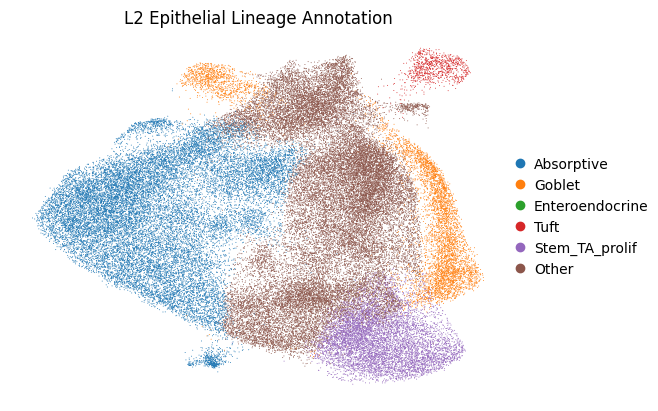

In [5]:
sc.pl.umap(adata,
           color=["L2_celltype_sub"],
           frameon=False,
           title="L2 Epithelial Lineage Annotation",  # 英文标题
)

### 吸收细胞

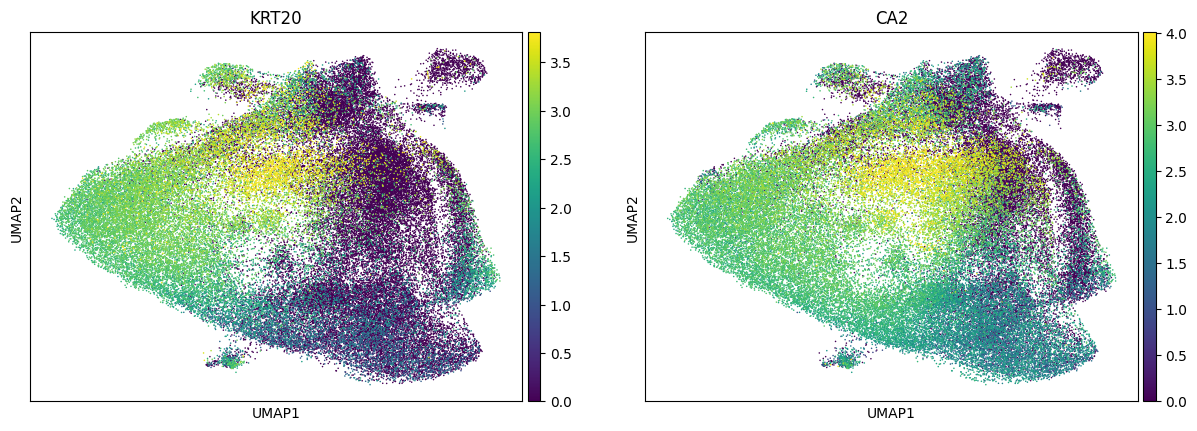

In [6]:
markers_absorptive = ["KRT20",   # 成熟结肠上皮
                      "CA1", "CA2",
                      "SLC26A3", # DRA，经典结肠吸收、
                      "ALDOB", "FABP1", "APOA1"
]
def safe_genes(genes, adata):
    return [g for g in genes if g in adata.var_names]

sc.pl.umap(adata, color=safe_genes(markers_absorptive, adata), ncols=3, cmap="viridis", vmax="p99", vmin=0, size=5,)

other细胞并不是成熟的结肠上皮细胞

### 杯状细胞

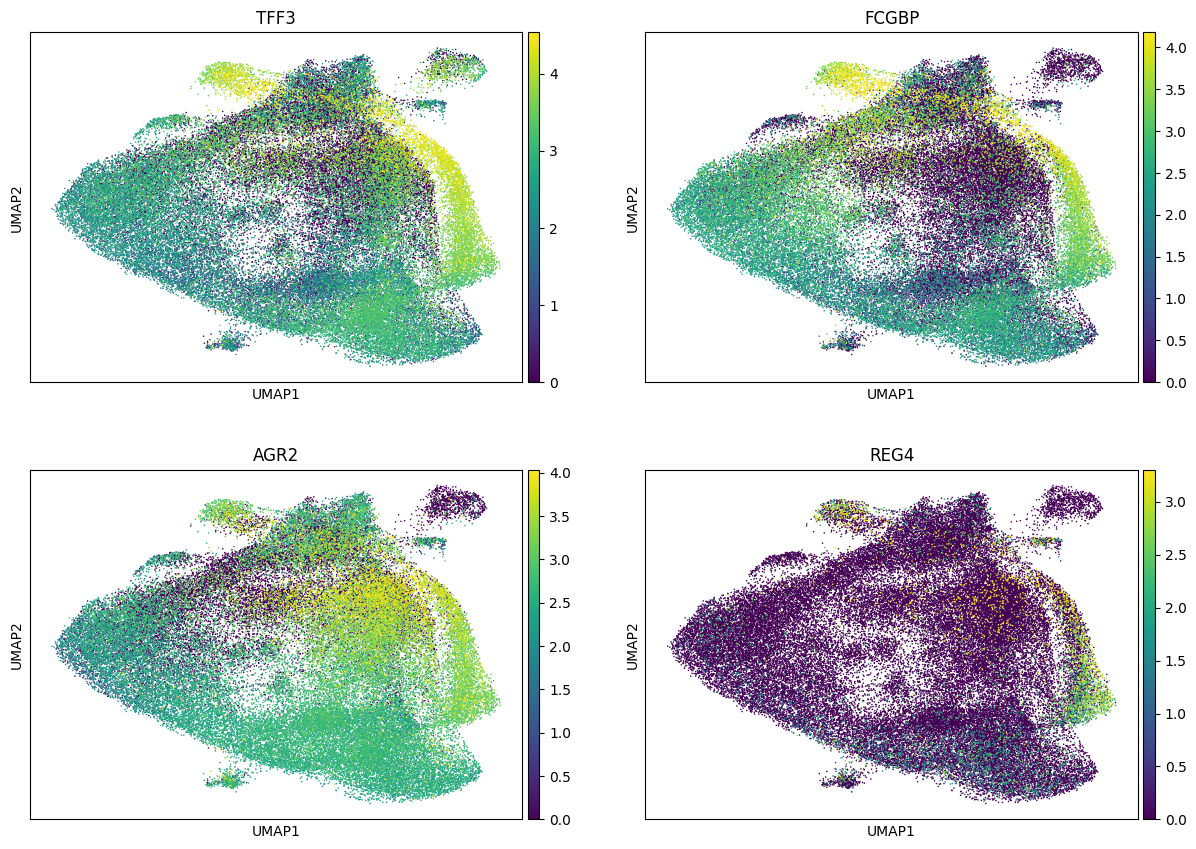

In [7]:
markers_goblet = ["MUC2","TFF3","FCGBP","SPINK4","AGR2","REG4"]
sc.pl.umap(adata,color=safe_genes(markers_goblet, adata),ncols=2,cmap="viridis",vmax="p99",vmin=0,size=5,)


### 干样/增殖细胞

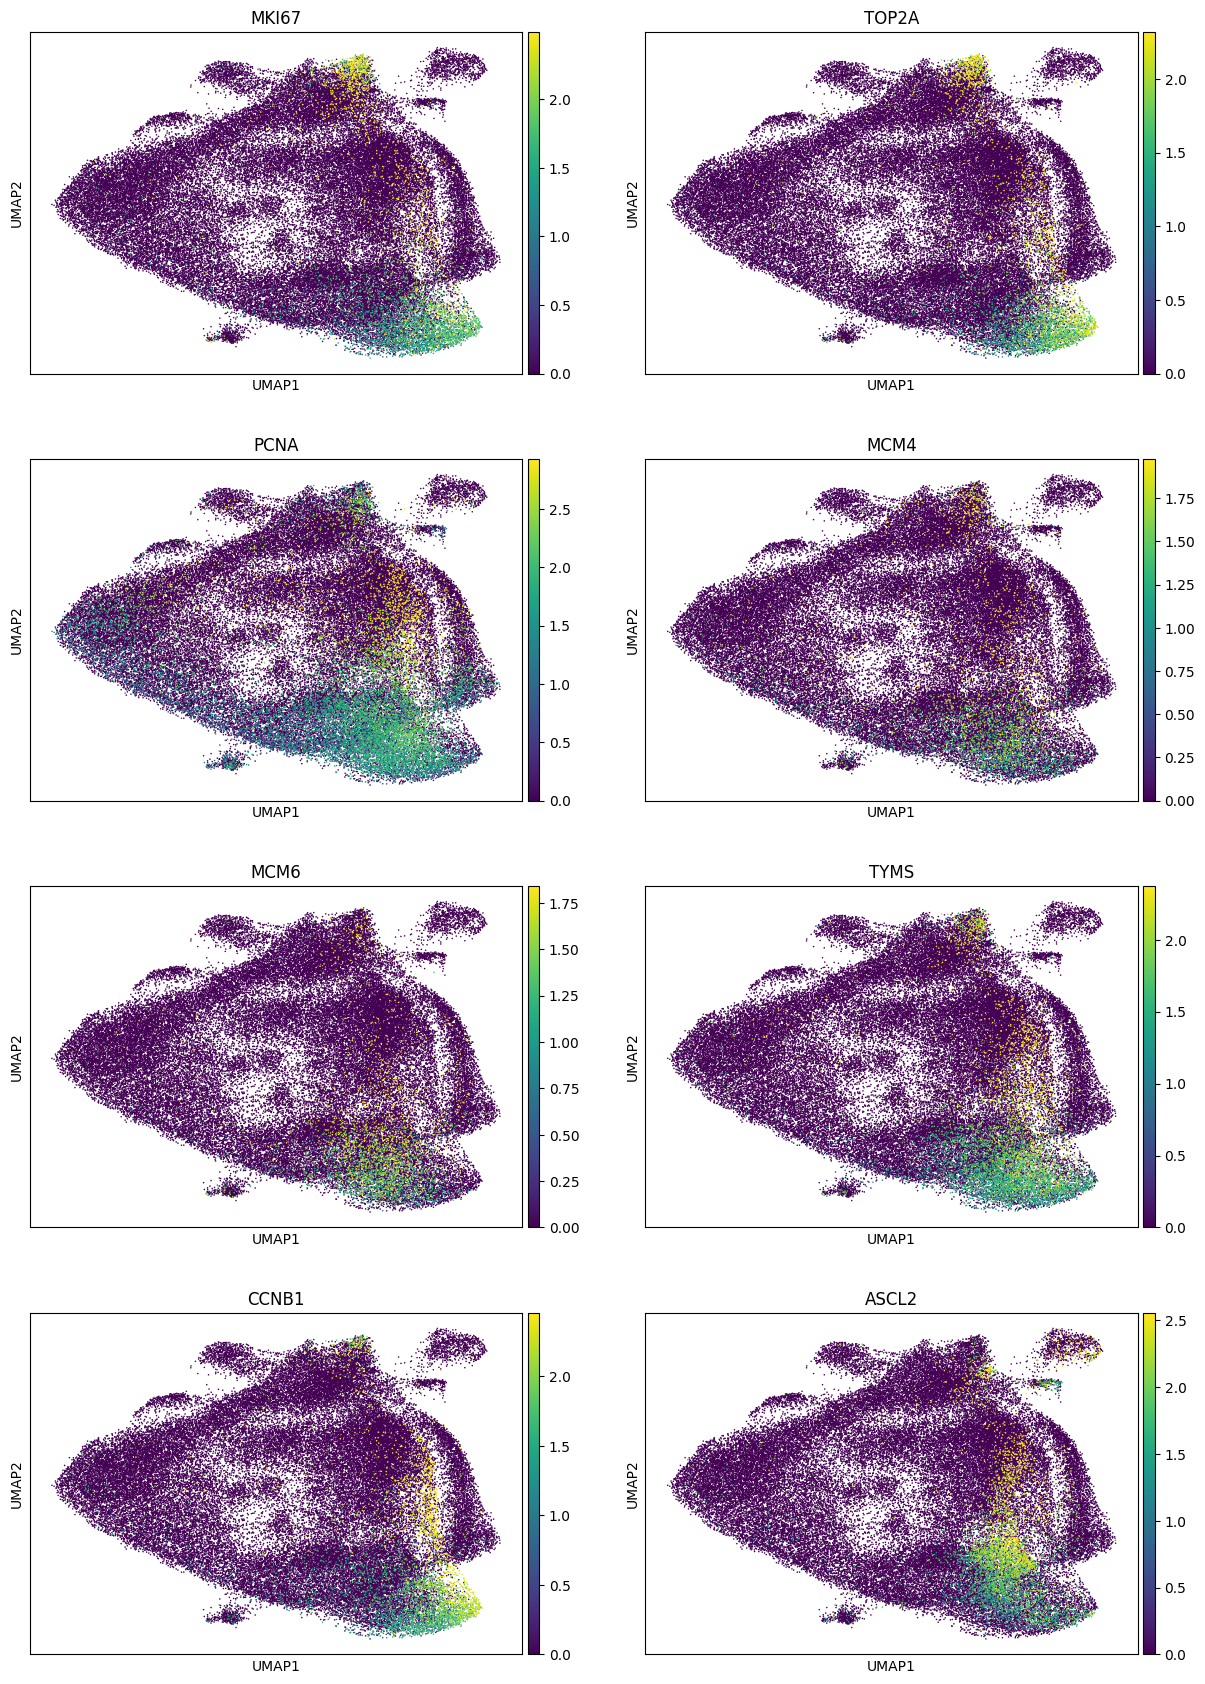

In [8]:
markers_stem_ta = ["MKI67","TOP2A","PCNA","MCM4", "MCM6","TYMS","CCNB1","LGR5","ASCL2"
]
sc.pl.umap(adata,color=safe_genes(markers_stem_ta, adata),ncols=2,cmap="viridis",vmax="p99",vmin=0,size=5,)

### Tuft细胞

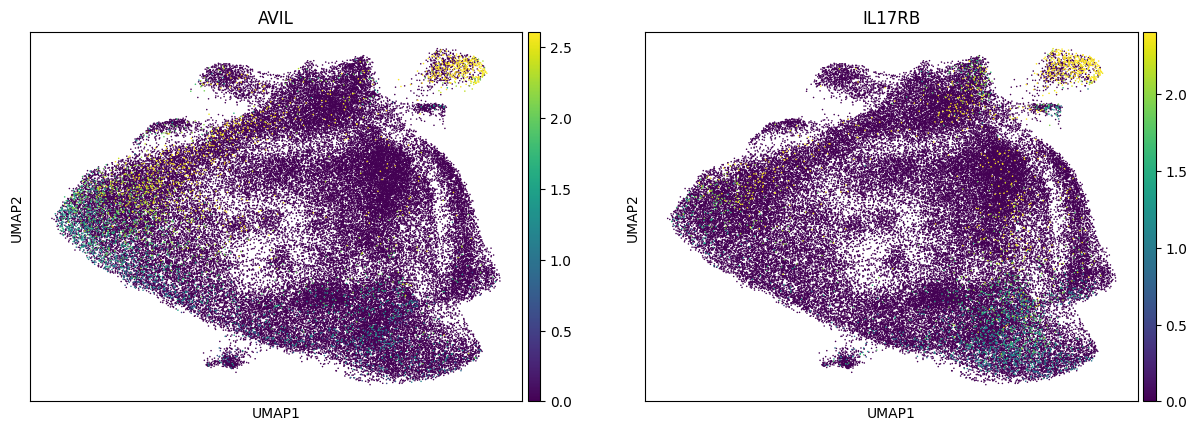

In [9]:
markers_tuft = ["DCLK1","POU2F3","TRPM5","AVIL","GFI1B","IL17RB"
]
sc.pl.umap(adata,color=safe_genes(markers_tuft, adata),ncols=3,cmap="viridis",vmax="p99",vmin=0,size=5,)

### 针对Other细胞

KRT20几乎不表达：绝对不是成熟吸收细胞

MKI67和TOP2A也不表达：不是TA

**猜测可能是早期未成熟的吸收细胞**

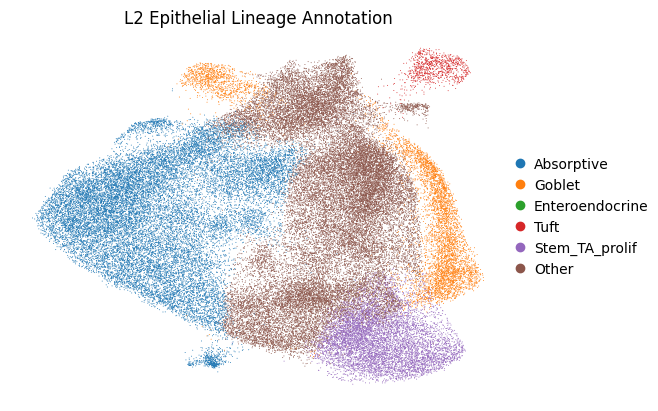

In [10]:
sc.pl.umap(adata,color=["L2_celltype_sub"],frameon=False,title="L2 Epithelial Lineage Annotation",)

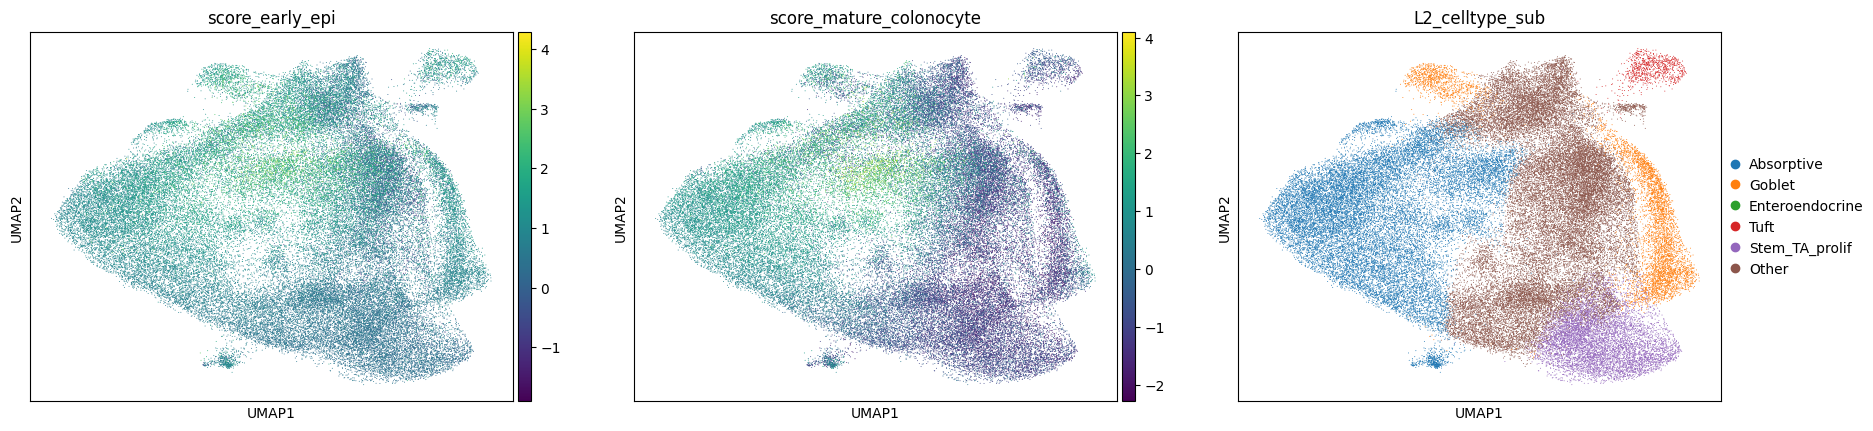

In [11]:
early_genes   = ["EPCAM","KRT8","KRT18","KRT19","MUC13","TACSTD2"]
mature_genes  = ["KRT20","CA1","CA2","SLC26A3","ALDOB","FABP1"]

sc.tl.score_genes(adata, [g for g in early_genes  if g in adata.var_names], score_name="score_early_epi")
sc.tl.score_genes(adata, [g for g in mature_genes if g in adata.var_names], score_name="score_mature_colonocyte")

sc.pl.umap(
    adata,
    color=["score_early_epi","score_mature_colonocyte","L2_celltype_sub"],
    ncols=3
)

### Other为未成熟吸收细胞

In [12]:
adata.obs["L2_celltype_sub"].value_counts()

L2_celltype_sub
Other              29774
Absorptive         21075
Stem_TA_prolif      7424
Goblet              5683
Tuft                 899
Enteroendocrine        0
Name: count, dtype: int64

In [13]:
import pandas as pd

adata.obs["L2_celltype_sub"] = (
    adata.obs["L2_celltype_sub"]
    .replace({"Other": "Early_Absorptive"})
    .astype("category")
)
adata

AnnData object with n_obs × n_vars = 64855 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'L2_celltype_sub', 'score_early_epi', 'score_mature_colonocyte'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'GSE_colors', 'L1_lineage_colors', 'L2_celltype_colors', 'REFERENCE_MANU', 'hvg', 'leiden_0.3', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_0.7', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap', 'L2_celltype_sub_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

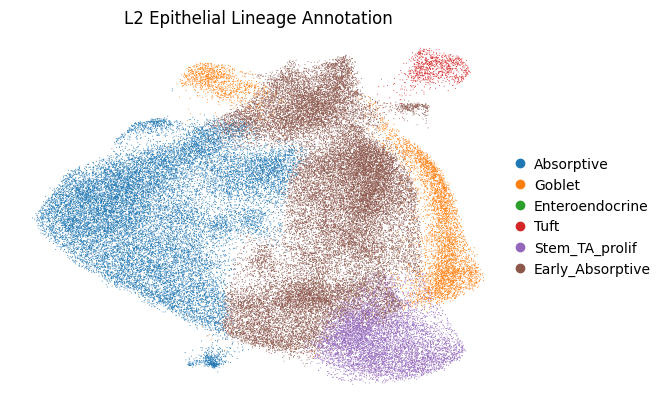

In [14]:
sc.pl.umap(adata,color=["L2_celltype_sub"],frameon=False,title="L2 Epithelial Lineage Annotation",)

## 保存

In [15]:
adata

AnnData object with n_obs × n_vars = 64855 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'L2_celltype_sub', 'score_early_epi', 'score_mature_colonocyte'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'GSE_colors', 'L1_lineage_colors', 'L2_celltype_colors', 'REFERENCE_MANU', 'hvg', 'leiden_0.3', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_0.7', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap', 'L2_celltype_sub_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [17]:
adata.obs.head()

,GSM,GSE,group,leiden_scVI_0.2,L1_lineage,L2_celltype_sub,score_early_epi,score_mature_colonocyte
GSM8980879_HC89_CELL8771_N2,GSM8980879,GSE296969,HC,2,Epithelial,Early_Absorptive,-0.791431,-0.807582
GSM8980879_HC89_CELL20377_N1,GSM8980879,GSE296969,HC,2,Epithelial,Early_Absorptive,-0.588757,-0.600773
GSM8980880_HC90_CELL16402_N1,GSM8980880,GSE296969,HC,2,Epithelial,Early_Absorptive,0.955608,-1.279988
GSM8980880_HC90_CELL75873_N1,GSM8980880,GSE296969,HC,2,Epithelial,Early_Absorptive,0.440591,-1.372034
GSM8980885_HC91_CELL1540_N2,GSM8980885,GSE296969,HC,2,Epithelial,Early_Absorptive,-0.727188,-1.204381


In [18]:
wanted_cols = [
    "GSM", "GSE", "group",
    "L1_lineage",             
    "L2_celltype_sub",        # 最终子类（回收后已含 Other）
]
out_cols = [c for c in wanted_cols if c in adata.obs.columns]

adata.obs[out_cols].to_csv(OUT_CSV, index=True)
print(f"[Saved per-cell table] -> {OUT_CSV}")

[Saved per-cell table] -> /mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data/06_annotation/L3/epithelial/L3_epithelial_summary.csv
